# Deadline Predictor V9 (Final Robust Version)

## Objective
To provide a robust, statistically validated deadline prediction model.

### Key Features
- **Multi-Model Comparison**: Dummy, Random Forest, XGBoost, SVM
- **GridSearch Hyperparameter Tuning**: Optimize best model
- **4-Class Classification**: Quick (<=3d), Medium (<=7d), Extended (<=14d), Long (>14d)
- **Oversampling**: Balance minority classes
- **Quantile Regression**: 90% Confidence Interval

---

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingRegressor
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report, accuracy_score, mean_absolute_error, r2_score
from sklearn.utils import resample
from sklearn.dummy import DummyClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
import joblib

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

# DATA PATH
DATA_PATH = r"PM_Kaggle_dataset/Combined_Aurora_Mesos_V5.csv"

In [2]:
# === 1. Data Loading & Preprocessing ===
print("Loading Data...")
df = pd.read_csv(DATA_PATH)
df.columns = [c.strip().replace(' ', '_').lower() for c in df.columns]

# Text Feature
if 'description' not in df.columns:
    df['description'] = ''
df['text_feature'] = df['summary'].fillna('') + " " + df['description'].fillna('')

# Components Feature
df['components'] = df['components'].fillna('')

# Filtering
df = df.dropna(subset=['resolution_days'])
df = df[(df['resolution_days'] >= 0.01) & (df['resolution_days'] <= 30)]
df = df[df['story_points'] > 0]

print(f"Final Dataset Size: {len(df)}")

Loading Data...
Final Dataset Size: 1171



=== Class Distribution ===
duration_class
Quick       411
Long        315
Extended    237
Medium      208
Name: count, dtype: int64


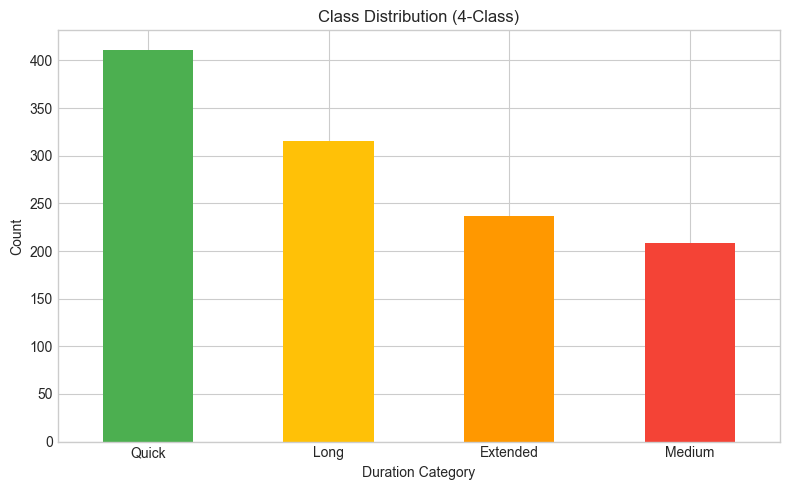

In [3]:
# === 2. 4-Class Definition ===
def categorize_duration(days):
    if days <= 3:
        return "Quick"
    elif days <= 7:
        return "Medium"
    elif days <= 14:
        return "Extended"
    else:
        return "Long"

df['duration_class'] = df['resolution_days'].apply(categorize_duration)

# Class Distribution
print("\n=== Class Distribution ===")
class_counts = df['duration_class'].value_counts()
print(class_counts)

plt.figure(figsize=(8, 5))
class_counts.plot(kind='bar', color=['#4CAF50', '#FFC107', '#FF9800', '#F44336'])
plt.title('Class Distribution (4-Class)')
plt.xlabel('Duration Category')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [4]:
# === 3. Feature Engineering ===
le = LabelEncoder()
df['target_encoded'] = le.fit_transform(df['duration_class'])
class_names = le.classes_

X = df[['story_points', 'issuetype', 'priority', 'project', 'text_feature', 'components']]
y_class = df['target_encoded']
y_reg = df['resolution_days']

# Split
X_train, X_test, y_class_train, y_class_test, y_reg_train, y_reg_test = train_test_split(
    X, y_class, y_reg, test_size=0.2, random_state=42, stratify=y_class
)

print(f"Train Size: {len(X_train)}, Test Size: {len(X_test)}")

Train Size: 936, Test Size: 235


In [5]:
# === 4. Oversampling ===
train_data = X_train.copy()
train_data['target'] = y_class_train.values

max_count = train_data['target'].value_counts().max()
print(f"\n=== Oversampling to {max_count} samples per class ===")

balanced_chunks = []
for cls, group in train_data.groupby('target'):
    resampled = resample(group, replace=True, n_samples=max_count, random_state=42)
    balanced_chunks.append(resampled)

train_balanced = pd.concat(balanced_chunks)
X_train_bal = train_balanced.drop('target', axis=1)
y_train_bal = train_balanced['target']

print(f"Balanced Train Size: {len(X_train_bal)}")


=== Oversampling to 329 samples per class ===
Balanced Train Size: 1316


In [6]:
# === 5. Preprocessing Pipeline ===
# Define a function for component tokenization (needed for pickling)
def comma_tokenizer(text):
    return text.split(',')

preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', ['story_points']),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), ['issuetype', 'priority', 'project']),
        ('text', TfidfVectorizer(max_features=150, stop_words='english'), 'text_feature'),
        ('comps', TfidfVectorizer(max_features=30, tokenizer=comma_tokenizer, token_pattern=None), 'components')
    ]
)

## Multi-Model Comparison

In [7]:
# Define Models
models = {
    'Dummy (Baseline)': DummyClassifier(strategy='stratified', random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=300, max_depth=20, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=300, max_depth=10, learning_rate=0.1, random_state=42, eval_metric='mlogloss'),
    'SVM (Linear)': SVC(kernel='linear', probability=True, random_state=42)
}

results = []

print("=== Training All Models ===")
for name, model in models.items():
    print(f"\nTraining {name}...")
    
    pipe = Pipeline([('prep', preprocessor), ('clf', model)])
    pipe.fit(X_train_bal, y_train_bal)
    
    y_pred = pipe.predict(X_test)
    acc = accuracy_score(y_class_test, y_pred)
    
    results.append({'Model': name, 'Accuracy': acc})
    print(f"  Accuracy: {acc:.4f}")

# Summary Table
results_df = pd.DataFrame(results).sort_values('Accuracy', ascending=False)
print("\n=== Model Comparison ===")
print(results_df.to_string(index=False))

=== Training All Models ===

Training Dummy (Baseline)...
  Accuracy: 0.2426

Training Random Forest...
  Accuracy: 0.4426

Training XGBoost...
  Accuracy: 0.3660

Training SVM (Linear)...
  Accuracy: 0.3191

=== Model Comparison ===
           Model  Accuracy
   Random Forest  0.442553
         XGBoost  0.365957
    SVM (Linear)  0.319149
Dummy (Baseline)  0.242553


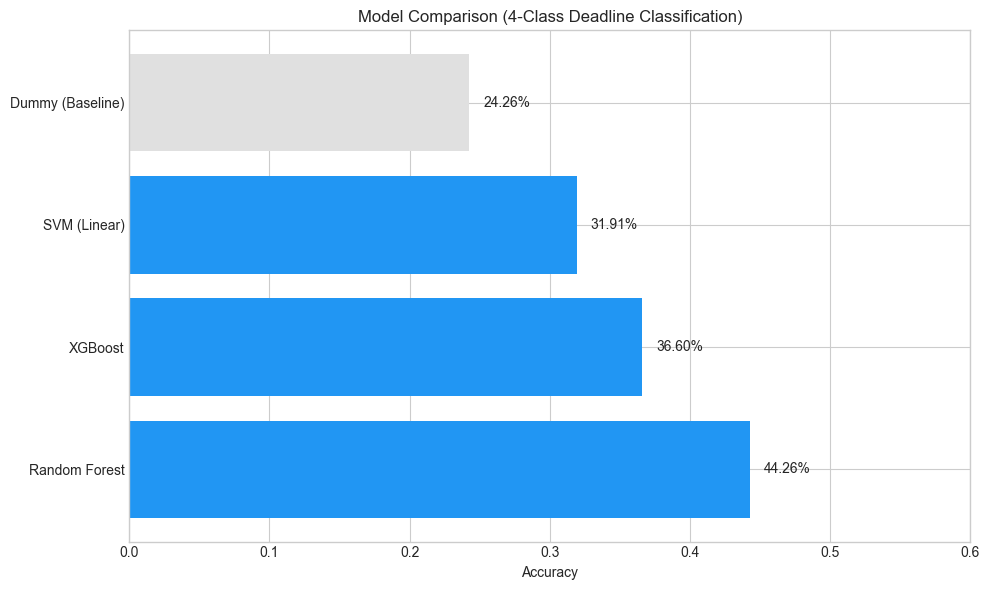

In [8]:
# Plot Comparison
plt.figure(figsize=(10, 6))
colors = ['#E0E0E0' if 'Dummy' in m else '#2196F3' for m in results_df['Model']]
bars = plt.barh(results_df['Model'], results_df['Accuracy'], color=colors)
plt.xlabel('Accuracy')
plt.title('Model Comparison (4-Class Deadline Classification)')
plt.xlim(0, 0.6)

for bar, acc in zip(bars, results_df['Accuracy']):
    plt.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2, f'{acc:.2%}', va='center')

plt.tight_layout()
plt.show()

## Best Model with GridSearch Hyperparameter Tuning

In [9]:
# Auto-select Best Model from Comparison (excluding Dummy)
best_model_name = results_df[~results_df['Model'].str.contains('Dummy')].iloc[0]['Model']
best_acc_initial = results_df[~results_df['Model'].str.contains('Dummy')].iloc[0]['Accuracy']

print(f"\n=== Best Model: {best_model_name} (Initial Accuracy: {best_acc_initial:.4f}) ===")
print("\nApplying GridSearch for Hyperparameter Tuning...")

# Define hyperparameter grid based on best model type
if best_model_name == 'Random Forest':
    base_model = RandomForestClassifier(random_state=42)
    param_grid = {
        'clf__n_estimators': [200, 300, 400],
        'clf__max_depth': [15, 20, 25],
        'clf__min_samples_split': [2, 5]
    }
elif best_model_name == 'XGBoost':
    base_model = XGBClassifier(random_state=42, eval_metric='mlogloss')
    param_grid = {
        'clf__n_estimators': [200, 300],
        'clf__max_depth': [6, 10],
        'clf__learning_rate': [0.05, 0.1]
    }
else:  # SVM or others
    base_model = SVC(kernel='linear', probability=True, random_state=42)
    param_grid = {
        'clf__C': [0.1, 1.0, 10.0]
    }

# Create pipeline and run GridSearch
pipeline = Pipeline([('prep', preprocessor), ('clf', base_model)])
grid_search = GridSearchCV(pipeline, param_grid, cv=3, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train_bal, y_train_bal)

# Get best estimator
best_clf = grid_search.best_estimator_
y_pred_best = best_clf.predict(X_test)
best_acc = accuracy_score(y_class_test, y_pred_best)

print(f"\nBest Hyperparameters: {grid_search.best_params_}")
print(f"Tuned Accuracy: {best_acc:.4f}")
print(classification_report(y_class_test, y_pred_best, target_names=class_names))


=== Best Model: Random Forest (Initial Accuracy: 0.4426) ===

Applying GridSearch for Hyperparameter Tuning...

Best Hyperparameters: {'clf__max_depth': 25, 'clf__min_samples_split': 2, 'clf__n_estimators': 300}
Tuned Accuracy: 0.4128
              precision    recall  f1-score   support

    Extended       0.32      0.23      0.27        48
        Long       0.39      0.52      0.45        63
      Medium       0.19      0.12      0.14        42
       Quick       0.54      0.59      0.56        82

    accuracy                           0.41       235
   macro avg       0.36      0.36      0.36       235
weighted avg       0.39      0.41      0.40       235



## Quantile Regression (Intervals)

In [10]:
quantiles = [0.05, 0.50, 0.95]
qr_models = {}
qr_preds = {}

print("Training Quantile Regressors...")
for alpha in quantiles:
    reg = Pipeline([
        ('prep', preprocessor), 
        ('reg', GradientBoostingRegressor(loss='quantile', alpha=alpha, n_estimators=200, max_depth=5, learning_rate=0.1, random_state=42))
    ])
    reg.fit(X_train, y_reg_train)
    qr_models[alpha] = reg
    qr_preds[alpha] = reg.predict(X_test)

print("Done.")

Training Quantile Regressors...
Done.


In [11]:
# Quantile Evaluation
res_df = pd.DataFrame({'Actual': y_reg_test})
res_df['Lower'] = qr_preds[0.05]
res_df['Median_Pred'] = qr_preds[0.50]
res_df['Upper'] = qr_preds[0.95]

coverage = ((res_df['Actual'] >= res_df['Lower']) & (res_df['Actual'] <= res_df['Upper'])).mean()
avg_width = (res_df['Upper'] - res_df['Lower']).mean()
mae = mean_absolute_error(res_df['Actual'], res_df['Median_Pred'])

print(f"Interval Metrics (N={len(res_df)}):")
print(f"  Coverage (Target 90%): {coverage:.2%}")
print(f"  Avg Interval Width: {avg_width:.2f} days")
print(f"  Median Prediction MAE: {mae:.2f} days")

Interval Metrics (N=235):
  Coverage (Target 90%): 88.09%
  Avg Interval Width: 26.36 days
  Median Prediction MAE: 6.16 days


## Statistical Validation (Wilcoxon)

In [12]:
global_median = y_reg_train.median()
res_df['Baseline_Pred'] = global_median

res_df['AE_Model'] = np.abs(res_df['Actual'] - res_df['Median_Pred'])
res_df['AE_Baseline'] = np.abs(res_df['Actual'] - res_df['Baseline_Pred'])

stat, p_value = stats.wilcoxon(res_df['AE_Model'], res_df['AE_Baseline'], alternative='less')

print(f"Statistical Test (Wilcoxon Signed-Rank):")
print(f"  Baseline MAE: {res_df['AE_Baseline'].mean():.2f}")
print(f"  Model MAE: {res_df['AE_Model'].mean():.2f}")
print(f"  P-Value: {p_value:.6f}")

if p_value < 0.05:
    print("  RESULT: Model significantly outperforms Baseline (p < 0.05).")
else:
    print("  RESULT: No significant difference found.")

Statistical Test (Wilcoxon Signed-Rank):
  Baseline MAE: 6.83
  Model MAE: 6.16
  P-Value: 0.001657
  RESULT: Model significantly outperforms Baseline (p < 0.05).


In [13]:
# === Test Cases & Save ===

def predict_final(story_points, priority, issuetype, project, summary, components):
    input_data = pd.DataFrame([{
        'story_points': story_points,
        'priority': priority,
        'issuetype': issuetype,
        'project': project,
        'text_feature': summary,
        'components': components
    }])
    
    cat_idx = best_clf.predict(input_data)[0]
    category = le.inverse_transform([cat_idx])[0]
    
    lower = max(0.1, qr_models[0.05].predict(input_data)[0])
    median = qr_models[0.50].predict(input_data)[0]
    upper = qr_models[0.95].predict(input_data)[0]
    
    print(f"--- Test Case: {summary} ---")
    print(f"  Category: {category}")
    print(f"  Interval: {lower:.1f} - {upper:.1f} days (Median: {median:.1f})")
    return category, lower, median, upper

# Run
predict_final(3.0, 'Major', 'Story', 'Aurora', 'Refactor backend API', 'Server')
predict_final(1.0, 'Minor', 'Bug', 'Mesos', 'Fix typos in documentation', 'Documentation')
predict_final(8.0, 'Critical', 'Story', 'Aurora', 'Implement new authentication system', 'Security')

print(f"\nBest Classifier: {best_model_name}")
print(f"Best Hyperparameters: {grid_search.best_params_}")

--- Test Case: Refactor backend API ---
  Category: Medium
  Interval: 0.1 - 26.4 days (Median: 7.0)
--- Test Case: Fix typos in documentation ---
  Category: Quick
  Interval: 0.1 - 26.4 days (Median: 2.8)
--- Test Case: Implement new authentication system ---
  Category: Long
  Interval: 0.1 - 26.5 days (Median: 24.6)

Best Classifier: Random Forest
Best Hyperparameters: {'clf__max_depth': 25, 'clf__min_samples_split': 2, 'clf__n_estimators': 300}


# === 6. Saving Models for App Integration ===
This section saves the trained models so they can be loaded by `app.py`.

In [14]:
# Ensure models directory exists
import os
if not os.path.exists('models'):
    os.makedirs('models')

# Save Classifier and Encoder
joblib.dump(best_clf, 'models/deadline_v9_classifier.joblib')
joblib.dump(le, 'models/deadline_v9_label_encoder.joblib')

# Save Quantile Models (Dictionary)
joblib.dump(qr_models, 'models/deadline_v9_quantiles.joblib')

print("Models saved to models/ directory:")
print("- models/deadline_v9_classifier.joblib")
print("- models/deadline_v9_label_encoder.joblib")
print("- models/deadline_v9_quantiles.joblib")

Models saved to models/ directory:
- models/deadline_v9_classifier.joblib
- models/deadline_v9_label_encoder.joblib
- models/deadline_v9_quantiles.joblib
